In [1]:
import glob
import re
import os

first_layer_names = glob.glob('[0-9][0-9][0-9]',root_dir='./mached_catalog')
print(len(first_layer_names))
count = 0
print(os.getcwd())
for name in first_layer_names:
    second_layer_names = glob.glob('[0-9][0-9][0-9][0-9]*',   root_dir='./mached_catalog/'+name)
        
    for long_name in second_layer_names:
        if True == os.path.isfile('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w2_mached.csv'):
            count += 1
print(count)

359
/home/kangzihan/project_unTimely_light_curve
18221


In [2]:
import numpy as np

def calculate_magnitude(flux):
    if flux <= 0:
        return np.nan
    # if band == 'w1':
    #     return -2.5 * np.log10(flux/309.54)
    # if band == 'w2':
    #     return -2.5 * np.log10(flux/171.85)
    return 22.5 - 2.5 * np.log10(flux)

def calculate_error(flux,dflux):
    # mag_upper = calculate_magnitude(flux - dflux)
    # mag_lower = calculate_magnitude(flux + dflux)
    # dmag = (mag_upper - mag_lower) / 2
    # return dmag
    return (dflux * 1.0857)/flux

cal_mag_ufunc  = np.frompyfunc(calculate_magnitude,1,1)
cal_error_ufunc  = np.frompyfunc(calculate_error,2,1)



In [12]:
np.array([1, 2, 3])/np.array([4, 5, 6])

array([0.25, 0.4 , 0.5 ])

In [7]:

def make_single_light_curve(table, index):
    line = table.iloc[index]
    line_len = len(line)
    ra = line[0]
    dec = line[1]
    flux_unfiltered = line[3:line_len:3]
    flux = np.array(flux_unfiltered[flux_unfiltered.notnull()])
    dflux_unfiltered = line[4:line_len:3]
    dflux = np.array(dflux_unfiltered[dflux_unfiltered.notnull()])
    mjdmean_unfiltered = line[5:line_len:3]
    mjdmean = np.array(mjdmean_unfiltered[mjdmean_unfiltered.notnull()])
    assert len(flux)==len(dflux) and len(dflux)==len(mjdmean), 'light curve uncomplete!'
    mag = cal_mag_ufunc(flux)
    error = cal_error_ufunc(flux,dflux)
    # return ra,dec,mag, error, mjdmean, flux, dflux
    return ra,dec,mag, error, mjdmean


In [4]:
[2609.0, 3470.0, 4297.0, 4355.0, 5495.0, 6734.0, 6901.0, 7040.0, 8165.0, 8529.0, 8669.0, 9614.0, 10703.0, 12966.0, 13094.0, 15923.0, 16396.0, 16424.0, 17005.0, 17276.0, 18247.0, 19667.0, 20653.0, 20812.0, 21101.0, 21238.0, 21279.0, 22203.0, 23388.0, 24230.0, 24458.0, 26393.0, 26573.0, 28299.0, 28781.0, 28784.0, 29084.0, 30295.0, 30847.0, 31115.0, 32417.0]


[2609.0,
 3470.0,
 4297.0,
 4355.0,
 5495.0,
 6734.0,
 6901.0,
 7040.0,
 8165.0,
 8529.0,
 8669.0,
 9614.0,
 10703.0,
 12966.0,
 13094.0,
 15923.0,
 16396.0,
 16424.0,
 17005.0,
 17276.0,
 18247.0,
 19667.0,
 20653.0,
 20812.0,
 21101.0,
 21238.0,
 21279.0,
 22203.0,
 23388.0,
 24230.0,
 24458.0,
 26393.0,
 26573.0,
 28299.0,
 28781.0,
 28784.0,
 29084.0,
 30295.0,
 30847.0,
 31115.0,
 32417.0]

In [1]:
import pandas as pd
# input_table = pd.read_csv('./tempfiles/zjy_5560_untimely.csv')
input_table = pd.read_csv('./tempfiles/27154.csv')

input_table.columns

Index(['col1', 'col2', 'col3', 'col4', 'col5', 'col6', 'col7', 'col8', 'col9',
       'col10', 'col11', 'col12', 'col13', 'col14', 'col15', 'col16', 'col17',
       'col18', 'col19', 'col20', 'col21', 'col22', 'col23', 'col24', 'col25',
       'col26', 'col27', 'col28', 'col29', 'col30', 'col31', 'col32', 'col33',
       'RA', 'DEC', 'Unnamed: 0_1', 'ra_1', 'dec_1', 'id_in_matched_1',
       'long_name_1', 'id_w1_1', 'id_w2_1', 'distance_1', 'ra_block_1',
       'dec_block_1', 'Unnamed: 0_2', 'ra_2', 'dec_2', 'id_in_matched_2',
       'long_name_2', 'id_w1_2', 'id_w2_2', 'distance_2', 'ra_block_2',
       'dec_block_2', 'Separation_2', 'Separation'],
      dtype='object')

In [10]:
input_table['ra_1']

0        264.003433
1        266.881098
2        237.250966
3        285.248935
4        277.395523
            ...    
27149    285.391119
27150    266.217702
27151    244.689086
27152    285.463068
27153    277.677205
Name: ra_1, Length: 27154, dtype: float64

In [8]:
input_table['col1']

0        J173600.82-273628.1
1        J174731.46-291044.9
2        J154900.23-080714.3
3        J190059.74-364711.3
4        J182934.92-340040.4
                ...         
27149    J190133.86-365745.1
27150    J174452.24-285655.6
27151    J161845.38-142425.1
27152    J190151.13-365412.7
27153    J183042.52-341002.1
Name: col1, Length: 27154, dtype: object

In [8]:
import pandas as pd
import numpy as np
from util import make_single_light_curve

input_table = pd.read_csv('./special_marker_result.csv')

data_list = []
for i in range(len(input_table)):
    long_name = input_table.iloc[i]['long_name']
    name = long_name[0:3]
    id_w1 = input_table.iloc[i]['id_w1']
    id_w2 = input_table.iloc[i]['id_w2']
    table1 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w1_mached.csv')
    table2 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w2_mached.csv')
    ra1,dec1,mag1,error1,mjdmean1 = make_single_light_curve(table1,int(id_w1-1))
    ra2,dec2,mag2,error2,mjdmean2 = make_single_light_curve(table2,int(id_w2-1))
    data_list.append([[ra1,dec1,],[mag1,error1,mjdmean1],[ra2,dec2],[mag2,error2,mjdmean2]])
    print(i)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138


In [9]:
len(data_list)

139

In [10]:
import pickle
with open('special_marker_result_lc_data.pkl', 'wb') as f:
    pickle.dump(data_list, f)

In [15]:
data_list[12]

[[252.5178719, -20.0543376],
 [array([13.000630752017784, 12.970729610764122, 13.131205915305298,
         13.134387158546684, 13.051240011397683, 12.995402446945484,
         12.998150785636739, 13.017144827209023, 12.968212819694099,
         13.005815671706593, 13.036140614437878, 13.037026055088079,
         13.05851932524526, 13.093180022556364, 13.14995174197406,
         13.150099193050798], dtype=object),
  array([0.005738864374921999, 0.006007596490458867, 0.006319005342222236,
         0.006284151235459338, 0.005793394909414266, 0.005287438202399869,
         0.006052721469974112, 0.005808452854037882, 0.005996182452890013,
         0.005642131917550197, 0.0059862298050891456, 0.005907789390928412,
         0.006332763264668123, 0.006315286959722548, 0.00617284412653055,
         0.00589349937468456], dtype=object),
  array([55260.18976891, 55440.453875605, 56723.357369325, 56903.891607965,
         57085.33301484, 57264.261324055, 57452.42377862, 57623.077784155,
         57

In [17]:
data = pd.read_pickle('light_curve_data.pkl')
data[0]

[[array([12.886794955459532, 12.9172061994783, 12.975266111547,
         12.94544721626356, 12.970763781408277, 12.976223265437698,
         13.008451263216775, 12.99925833133925, 13.002493312946777,
         13.007009001577536, 13.006553013433379, 13.004072694475884,
         13.02100633582932, 12.995119755475963, 12.996123729251256,
         13.00880106021726, 12.994411414156366], dtype=object),
  array([0.004116384885301194, 0.003979755308651356, 0.005027973370479444,
         0.004011908527919772, 0.004607292260438101, 0.004559154984398184,
         0.004897048945874616, 0.005100643294160712, 0.004442099892187024,
         0.003980352560825295, 0.004615458337144496, 0.004700300996559825,
         0.00496708315661909, 0.004903644941758323, 0.004930341120633841,
         0.004781854219356951, 0.005018763391750447], dtype=object),
  array([55365.54350783, 55544.28358252, 56642.45933397, 56828.99668205,
         57007.580398845, 57192.262343525, 57366.705674425, 57556.483867785,
      

In [10]:
import pickle
with open('light_curve_data_27154.pkl', 'wb') as f:
    pickle.dump(data_list, f)

In [11]:
import pickle
with open('light_curve_data_27154.pkl', 'rb') as f:
    data_list = pickle.load(f)


In [18]:
import numpy as np
sd_list = []
sigma_list = []
mean_mag_list = []
delta_w2_list = []
for line in data_list:
    mag2 = line[3][0]
    err2 = line[3][1]
    sd_list.append(np.std(mag2))
    mean_mag_list.append(np.mean(mag2))
    sigma_list.append(np.mean(err2))
    delta_w2_list.append(np.max(mag2) - np.min(mag2))


In [28]:
more_than_20 = np.divide(sd_list,sigma_list)>20
print(more_than_20)

[ True  True False ...  True  True  True]


In [31]:
less_than_20 = ~more_than_20

Text(0, 0.5, 'Sigma')

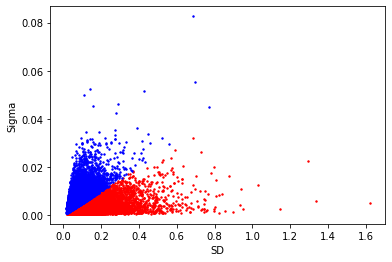

In [32]:
import matplotlib.pyplot as plt
plt.scatter(np.array(sd_list)[more_than_20],np.array(sigma_list)[more_than_20],s=2,c='r')
plt.scatter(np.array(sd_list)[less_than_20],np.array(sigma_list)[less_than_20],s=2,c='b')
plt.xlabel('SD')
plt.ylabel('Sigma')

Text(0, 0.5, 'SD/sigma')

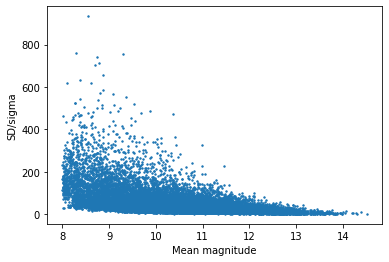

In [20]:
plt.scatter(mean_mag_list, np.divide(sd_list,sigma_list),s=2)
# plt.ylim(0,100)
plt.xlabel('Mean magnitude')
plt.ylabel('SD/sigma')

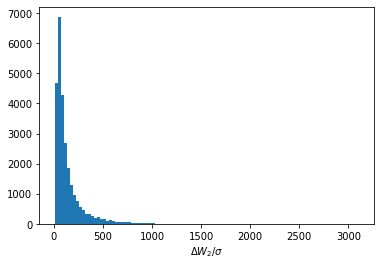

In [21]:
plt.hist(np.divide(delta_w2_list,sigma_list),bins=100)
plt.xlabel('$\Delta W_2/\sigma$')
plt.show()

In [38]:
more_than_3 = np.divide(delta_w2_list,sigma_list)>20
less_than_3 = ~more_than_3

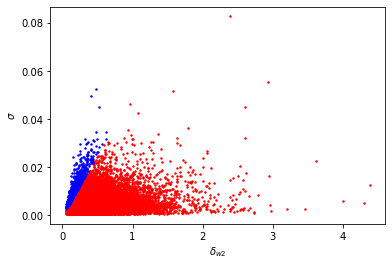

In [39]:
plt.scatter(np.array(delta_w2_list)[more_than_3],np.array(sigma_list)[more_than_3],s=2,c='r')
plt.scatter(np.array(delta_w2_list)[less_than_3],np.array(sigma_list)[less_than_3],s=2,c='b')
plt.xlabel(r'$\delta_{w2}$')
plt.ylabel(r'$\sigma$')
plt.show()

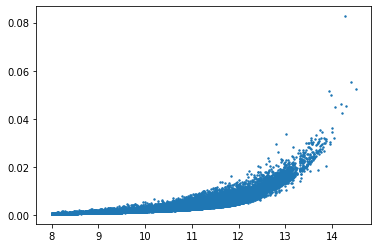

In [26]:
plt.scatter(mean_mag_list, sigma_list,s=2)

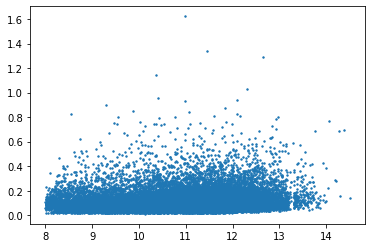

In [27]:
plt.scatter(mean_mag_list, sd_list,s=2)

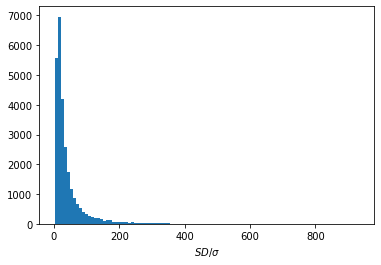

In [24]:
plt.hist(np.divide(sd_list,sigma_list),bins=100)
plt.xlabel('$SD/\sigma$')
plt.show()

/home/kangzihan/project_unTimely_light_curve
62.1138537 , 52.7336182 ; 62.1138537 , 52.7336182


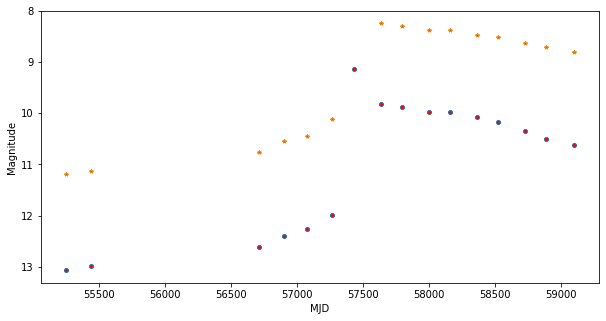

In [6]:
import os
import pandas as pd
from util import make_single_light_curve
import matplotlib.pyplot as plt 
print(os.getcwd())
name = '061'
long_name = '0616p530'

# table = pd.read_csv('./mached_catalog/116/1165p287/1165p287_w1_mached.csv')
table1 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w1_mached.csv')
table2 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w2_mached.csv')

import matplotlib.pyplot as plt
id_w1 = 32611
id_w2 = 32603
# ra1,dec1,mag1,error1,mjdmean1,flux1,dflux1 = make_single_light_curve(table1,int(id_w1-1))
# ra2,dec2,mag2,error2,mjdmean2,flux2,dflux2 = make_single_light_curve(table2,int(id_w2-1))
ra1,dec1,mag1,error1,mjdmean1 = make_single_light_curve(table1,int(id_w1-1))
ra2,dec2,mag2,error2,mjdmean2 = make_single_light_curve(table2,int(id_w2-1))

print(ra1,',',dec1,';',ra2,',',dec2)
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(111)
ax.invert_yaxis()

plt.xlabel('MJD')
plt.ylabel('Magnitude')
plt.errorbar(mjdmean1,mag1,error1,fmt='o',ms=4, mfc='r', elinewidth=1, capsize=2)

plt.errorbar(mjdmean2,mag2,error2,fmt='*',ms=4, mfc='g', elinewidth=1, capsize=2)
plt.show()
# plt.errorbar(mjdmean1,flux1,dflux1,fmt='o',ms=4, mfc='r', elinewidth=1, capsize=2)

# plt.errorbar(mjdmean2,flux2,dflux2,fmt='*',ms=4, mfc='g', elinewidth=1, capsize=2)
plt.show()


In [ ]:
special_long_name_list = ['0145m727', '0346p560', '0300p605',  '0079m682', '1250m379','0418m697', '0132m379',  '0890m667', '0194m727', '0194m727', '0330p605', '0616p530',  '0806m591', '0830m682',  '3404m228','1154m046', '1164m743', '0000p636', '0030m122', '0047p514', '0061m122', '0110p166', '0170m137', '0185m500']
id_w1_list = [19080, 26158, 14941,  27012,31655,6041, 4944,  3277, 48368, 36866, 19642, 32611, 23581, 12041, 4134, 26395, 18856, 5202, 13375, 35918, 8359, 6442, 21509, 19177]
id_w2_list = [19069, 26127, 14939,  26164,31677,5918, 4753,  3277, 47663, 36302, 19632, 32603, 23293, 12046, 3956, 26064, 18713, 5215, 12859, 35808, 8092, 6189, 20717, 18501]

In [2]:
print(mag1)

[9.592224830180015 9.597904276698282 9.605644689974799 9.60206383389987
 9.596878350784486 9.588755983995693 9.577825932609159 9.562725667244301
 9.551512161464908 9.536647794302374 9.529211075618655 9.525356815959995
 9.515704357102663 9.522100933934842 9.519600680886263 9.525090657657906
 9.525144851621556 9.52552211094882 9.51826767742158 9.51282580077548
 9.51393776754096 9.509362173888022 9.505990084032447 9.503952951678531
 9.497171466869991 9.491786116755286 9.484650306089282 9.475423179105707
 9.472038268887186 9.4844371592942 9.49745861525841 9.509908743093721
 9.52496524370961 9.535377856725658 9.554899161396836 9.569210385223155
 9.58710627941745 9.597922569470034 9.602041482649026 9.659492885119171
 9.656696708831042 9.657748213880527 9.663799074808265 9.666117602883107
 9.67248109972764 9.68299966395316 9.683177491231735 9.682661848026406
 9.673073475454057 9.666742140423478 9.658057445576041 9.625264787016082
 9.613766378531174 9.60667357077609 9.599189793938713 9.6004409

In [3]:
print(mjdmean1)

[55208.100422215 55218.12499085 55228.116476025 55238.107541725
 55248.13170707 55258.08939394 55268.080190965 55278.103591195
 55288.093695095 55298.116530785 55308.10633074 55318.095558215005
 55328.01868637 55338.073596305 55347.99625577 55357.98461827501
 55367.973172615 55377.994510825 55388.24734852 55398.26875428
 55408.256798345 55418.245426355 55428.23312092 55438.22094225
 55448.24122544 55458.26118813 55468.247847175 55478.233932295
 55488.22033556 55498.20635731 55508.22568745 55518.2450916 55528.23107372
 55538.217316215 55548.20318017001 55558.222276875 55568.274289955
 55578.359218115 55588.411095765 56644.783322785006 56654.798980235006
 56664.813935815 56674.795333505 56684.77621593 56694.78925043
 56704.801321115 56714.812682775 56724.789983445 56734.76607332
 56744.773936245 56750.402909255004 56775.251371345 56784.794018765
 56794.76380136 56804.798582475 56814.800002125005 56824.80103556
 56834.801493385006 56844.801634685005 56854.80132978 56864.800709665
 56874.7

In [33]:
# target_list = pd.read_csv('../catalogues/8.0-18.1_w1_co_above_0.6_var_table_new.csv')
target_list = pd.read_csv('./results/simbad_above_0.7_new_w1.csv')
target_list = target_list[target_list['main_type']=='Star']
print(len(target_list))


/tmp/ipykernel_8127/3626664175.py:2: DtypeWarning: Columns (27) have mixed types. Specify dtype option on import or set low_memory=False.
  target_list = pd.read_csv('./results/simbad_above_0.7_new_w1.csv')


122260


54.1258604 , 59.6801666 54.1258604 59.6801666


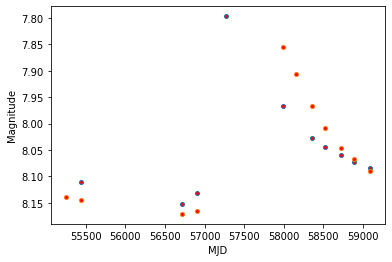

In [34]:
import os
import pandas as pd
from IPython.display import clear_output
import matplotlib.pyplot as plt


# target_list = pd.read_csv('./tempfiles/standstar_var_new.csv')


i = 0

while i < len(target_list):
    clear_output(wait=True)
    # ra,dec = target_list.iloc[i]['ra'],target_list.iloc[i]['dec']
    # print(ra,dec)
    long_name = target_list.iloc[i]['long_name']
    id_in_matched = target_list.iloc[i]['id_in_matched']
    # target_id = target_list.iloc[i]['TARGETID']
    id_w1 = target_list.iloc[i]['id_w1']
    id_w2 = target_list.iloc[i]['id_w2']
    name = long_name[0:3]
    table1 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w1_mached.csv')
    table2 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w2_mached.csv')
    ra1,dec1,mag1,error1,mjdmean1 = make_single_light_curve(table1,int(id_w1-1))
    ra2,dec2,mag2,error2,mjdmean2 = make_single_light_curve(table2,int(id_w2-1))
    # df1 = pd.DataFrame({'mag':mag1,'error':error1,'mjdmean':mjdmean1})
    # df2 = pd.DataFrame({'mag':mag2,'error':error2,'mjdmean':mjdmean2})
    # df1.to_csv('./tmp_data/w1/'+str(target_id)+'_'+str(ra)+'_'+str(dec)+'.csv',index=False)
    # df2.to_csv('./tmp_data/w2/'+str(target_id)+'_'+str(ra)+'_'+str(dec)+'.csv',index=False)
    # i += np.random.randint(1,50) 
    i+=1
    print(ra1,',',dec1,ra2,dec2)
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.invert_yaxis()
    plt.xlabel('MJD')
    plt.ylabel('Magnitude')
    plt.errorbar(mjdmean1,mag1,error1,fmt='o',ms=4, mfc='r', elinewidth=1, capsize=2)
    plt.errorbar(mjdmean2,mag2,error2,fmt='o',ms=4, mfc='r', elinewidth=1, capsize=2)
    plt.show()
    user_input = input('Do you want to continue? (y/n)')
    if user_input == 'n':
        break

269.3639558 , -38.5949567 作为一个重要的对比例子
282.5969059 , -8.4970424 +1

In [ ]:
import os
import pandas as pd
print(os.getcwd())
name = '347'
long_name = '3476m122'
# table = pd.read_csv('./mached_catalog/116/1165p287/1165p287_w1_mached.csv')
table1 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w1_mached.csv')
table2 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w2_mached.csv')

import matplotlib.pyplot as plt
id_w1 = 9892
id_w2 = 9517
ra1,dec1,mag1,error1,mjdmean1 = make_single_light_curve(table1,int(id_w1-1))
ra2,dec2,mag2,error2,mjdmean2 = make_single_light_curve(table2,int(id_w2-1))
print(ra1,',',dec1,';',ra2,',',dec2)
plt.figure(figsize=(10,5))


plt.xlabel('MJD')
plt.ylabel('Magnitude')
plt.errorbar(mjdmean1,mag1,error1,fmt='o',ms=4, mfc='r', elinewidth=1, capsize=2)

plt.errorbar(mjdmean2,mag2,error2,fmt='*',ms=4, mfc='g', elinewidth=1, capsize=2)
plt.show()

In [ ]:
len(mag1)

In [ ]:
count = 0
light_count = 0
for i in range(0,len(table)):
    flux,dflux,mjdmean = make_single_light_curve(table,i)
    if len(flux) >= 10:
        count += 1
    mean_flux = np.mean(flux)
    if mean_flux > 500:
        light_count += 1
print(count)
print(light_count)

In [ ]:
# def generage_name(ra,dec):
#     name = str(int(ra))[0:3]
#     if len(name) == 1:
#         name = '00' + name
#     elif len(name) == 2:
#         name = '0' + name
    
#     long_name_prefix = name + str(ra-int(ra))[2]
#     long_name_mid = 'm' if dec < 0 else 'p'

#     long_name_suffix = str(abs(int(dec)))[0:3]

#     if len(long_name_suffix) == 1:
#         long_name_suffix = '00' + long_name_suffix
#     elif len(long_name_suffix) == 2:
#         long_name_suffix = '0' + long_name_suffix

#     long_name = long_name_prefix + long_name_mid + long_name_suffix

#     return name, long_name

# 这是错误逻辑

In [ ]:
# import pandas as pd
# import numpy as np

# ra,dec,index = 21.23937,10.05593,32.0
# index = int(index)

# name, long_name = generage_name(ra,dec)
# table = pd.read_csv(table = pd.read_csv('./mached_catalog/%s/%s/%s_w1_mached.csv'%(name,long_name,long_name)))
# ra_in_table = table['ra'][index]
# dec_in_table = table['dec'][index]

# print(ra_in_table,dec_in_table)
# import matplotlib.pyplot as plt
# ra,dec,mag,error,mjdmean = make_single_light_curve(table,index)
# print(ra,',',dec)
# plt.errorbar(mjdmean,mag,error,fmt='o',ms=4, mfc='r', elinewidth=1, capsize=2)